# DP1 Magnification Bias Estimate

Estimate whether lensing magnification by the foreground halos could bias the close-pair color stack.

This notebook is intentionally approximate: it treats the foreground halo as an NFW lens, estimates the pair-level magnification amplitude from the foreground halo mass and pair separation, measures empirical catalog color-magnitude slopes for the background sample, and converts the achromatic magnitude perturbation into an expected color shift through those slopes.

In [21]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from astropy import units as u
from astropy.constants import G, c as SPEED_OF_LIGHT
from astropy.cosmology import Planck18 as cosmo
from IPython.display import Markdown, display

ROOT = Path.cwd()
if not (ROOT / "src" / "dusty_colors").exists():
    ROOT = Path.cwd().resolve().parents[0]
sys.path.insert(0, str(ROOT / "src"))

from dusty_colors.color_split_bias import build_radial_pair_table, radial_bin_label

STACK_ID = "dp1_default_pai24"
SAMPLE_ID = "dp1_pai24"
BIN_INDEX = 0
COLORS = ("g-z", "g-r", "r-i", "i-z")
MAG_BAND = "r"
AB_NJY_ZP = 31.4
CONCENTRATION = 10.0
N_MAG_BINS = 12

CONFIG_PATH = ROOT / "results" / "stacks" / STACK_ID / "config_resolved.yaml"
if not CONFIG_PATH.exists():
    CONFIG_PATH = ROOT / "configs" / "analyses" / f"{STACK_ID}.yaml"
SAMPLE_DIR = ROOT / "results" / "samples" / SAMPLE_ID
STACK_PATH = ROOT / "results" / "stacks" / STACK_ID / "stack_fcolors.npz"
OUT_DIR = ROOT / "results" / "magnification_bias" / STACK_ID
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"stack: {STACK_ID}")
print(f"config: {CONFIG_PATH}")
print(f"outputs: {OUT_DIR}")

stack: dp1_default_pai24
config: /Users/jfcrenshaw/Documents/dusty_colors/results/stacks/dp1_default_pai24/config_resolved.yaml
outputs: /Users/jfcrenshaw/Documents/dusty_colors/results/magnification_bias/dp1_default_pai24


In [22]:
with open(CONFIG_PATH) as handle:
    config = yaml.safe_load(handle)

analysis_config = config.get(
    "stack", config.get("analysis", {}).get("data", {}).get("stack", {})
)
r_edges = np.asarray(analysis_config["r_bin_edges"], dtype=float)
r_min, r_max = float(r_edges[BIN_INDEX]), float(r_edges[BIN_INDEX + 1])
bin_label = radial_bin_label(BIN_INDEX, r_min, r_max)

foreground = pd.read_parquet(SAMPLE_DIR / "foreground.parquet")
background = pd.read_parquet(SAMPLE_DIR / "background.parquet")
pairs = build_radial_pair_table(
    foreground,
    background,
    stack_id=STACK_ID,
    bin_index=BIN_INDEX,
    r_edges_kpc=r_edges,
)

fg_pair = foreground.iloc[pairs["foreground_index"].to_numpy(int)].reset_index(
    drop=True
)
bg_pair = background.iloc[pairs["background_index"].to_numpy(int)].reset_index(
    drop=True
)

stack_data = np.load(STACK_PATH) if STACK_PATH.exists() else None

display(
    pd.DataFrame(
        {
            "quantity": [
                "radial bin",
                "pair count",
                "median theta [arcsec]",
                "median r_perp [kpc]",
                "median log10 M_halo [Msun]",
                "median z_fg",
                "median z_bg",
            ],
            "value": [
                f"{r_min:g}-{r_max:g} kpc",
                len(pairs),
                np.nanmedian(pairs["theta_arcsec"]),
                np.nanmedian(pairs["r_perp_kpc"]),
                np.nanmedian(fg_pair["halo_mass_log"]),
                np.nanmedian(fg_pair["z_phot"]),
                np.nanmedian(bg_pair["z_phot"]),
            ],
        }
    )
)

,quantity,value
0,radial bin,10-15 kpc
1,pair count,111
2,median theta [arcsec],2.672524
3,median r_perp [kpc],12.644562
4,median log10 M_halo [Msun],11.122302
5,median z_fg,0.331685
6,median z_bg,0.773738


## NFW Magnification Model

For each foreground-background pair, the notebook uses the foreground halo mass, foreground and background photometric redshifts, and projected separation. The halo is approximated as an NFW profile with a fixed concentration. The result is a characteristic magnification amplitude, not a precision lensing model.

In [23]:
def _nfw_f(x):
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)
    lt = x < 1.0
    gt = x > 1.0
    eq = np.isclose(x, 1.0)
    with np.errstate(divide="ignore", invalid="ignore"):
        out[lt] = (
            1.0
            - 2.0
            / np.sqrt(1.0 - x[lt] ** 2)
            * np.arctanh(np.sqrt((1.0 - x[lt]) / (1.0 + x[lt])))
        ) / (x[lt] ** 2 - 1.0)
        out[gt] = (
            1.0
            - 2.0
            / np.sqrt(x[gt] ** 2 - 1.0)
            * np.arctan(np.sqrt((x[gt] - 1.0) / (1.0 + x[gt])))
        ) / (x[gt] ** 2 - 1.0)
    out[eq] = 1.0 / 3.0
    return out


def _nfw_g(x):
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)
    lt = x < 1.0
    gt = x > 1.0
    eq = np.isclose(x, 1.0)
    with np.errstate(divide="ignore", invalid="ignore"):
        out[lt] = np.log(x[lt] / 2.0) + (
            2.0
            / np.sqrt(1.0 - x[lt] ** 2)
            * np.arctanh(np.sqrt((1.0 - x[lt]) / (1.0 + x[lt])))
        )
        out[gt] = np.log(x[gt] / 2.0) + (
            2.0
            / np.sqrt(x[gt] ** 2 - 1.0)
            * np.arctan(np.sqrt((x[gt] - 1.0) / (1.0 + x[gt])))
        )
    out[eq] = 1.0 + np.log(0.5)
    return out


def sigma_crit_msun_mpc2(z_lens, z_source):
    if not np.isfinite(z_lens) or not np.isfinite(z_source) or z_source <= z_lens:
        return np.nan
    d_l = cosmo.angular_diameter_distance(z_lens)
    d_s = cosmo.angular_diameter_distance(z_source)
    d_ls = cosmo.angular_diameter_distance_z1z2(z_lens, z_source)
    return (SPEED_OF_LIGHT**2 / (4.0 * np.pi * G) * d_s / (d_l * d_ls)).to_value(
        u.Msun / u.Mpc**2
    )


def r200_from_mass_mpc(m200_msun, z_lens):
    rho_c = cosmo.critical_density(z_lens).to_value(u.Msun / u.Mpc**3)
    return (3.0 * m200_msun / (4.0 * np.pi * 200.0 * rho_c)) ** (1.0 / 3.0)


def nfw_magnification(
    log10_m200,
    z_lens,
    z_source,
    r_perp_kpc,
    *,
    concentration=CONCENTRATION,
    r200_mpc=np.nan,
):
    if (
        not np.isfinite(log10_m200)
        or not np.isfinite(z_lens)
        or not np.isfinite(z_source)
        or not np.isfinite(r_perp_kpc)
        or z_source <= z_lens
        or r_perp_kpc <= 0
        or concentration <= 0
    ):
        return {"mu": np.nan, "kappa": np.nan, "gamma": np.nan, "delta_mag": np.nan}

    m200 = 10.0 ** float(log10_m200)
    r200 = (
        float(r200_mpc)
        if np.isfinite(r200_mpc) and r200_mpc > 0
        else r200_from_mass_mpc(m200, z_lens)
    )
    rs = r200 / concentration
    norm = np.log(1.0 + concentration) - concentration / (1.0 + concentration)
    rho_s = m200 / (4.0 * np.pi * rs**3 * norm)
    sigcrit = sigma_crit_msun_mpc2(z_lens, z_source)
    if not np.isfinite(sigcrit) or sigcrit <= 0:
        return {"mu": np.nan, "kappa": np.nan, "gamma": np.nan, "delta_mag": np.nan}

    x = np.asarray([r_perp_kpc / 1000.0 / rs], dtype=float)
    kappa_s = rho_s * rs / sigcrit
    f_x = _nfw_f(x)[0]
    g_x = _nfw_g(x)[0]
    kappa = 2.0 * kappa_s * f_x
    gamma = 2.0 * kappa_s * (2.0 * g_x / x[0] ** 2 - f_x)
    denom = (1.0 - kappa) ** 2 - gamma**2
    mu = 1.0 / denom if denom != 0 else np.nan
    delta_mag = -2.5 * np.log10(mu) if np.isfinite(mu) and mu > 0 else np.nan
    return {"mu": mu, "kappa": kappa, "gamma": gamma, "delta_mag": delta_mag}

In [24]:
mag_rows = []
for i, pair in pairs.reset_index(drop=True).iterrows():
    fg = fg_pair.iloc[i]
    lens = nfw_magnification(
        fg.get("halo_mass_log", np.nan),
        pair["foreground_z"],
        pair["background_z"],
        pair["r_perp_kpc"],
        r200_mpc=fg.get("r200_mpc", np.nan),
    )
    mag_rows.append(
        {
            "pair_id": pair["pair_id"],
            "foreground_object_id": pair["foreground_object_id"],
            "background_object_id": pair["background_object_id"],
            "r_perp_kpc": pair["r_perp_kpc"],
            "theta_arcsec": pair["theta_arcsec"],
            "foreground_z": pair["foreground_z"],
            "background_z": pair["background_z"],
            "foreground_halo_mass_log": fg.get("halo_mass_log", np.nan),
            "foreground_r200_mpc": fg.get("r200_mpc", np.nan),
            **lens,
        }
    )

magnification = pd.DataFrame(mag_rows)
magnification["mu_minus_1"] = magnification["mu"] - 1.0
magnification.to_csv(
    OUT_DIR / f"{bin_label}_pair_magnification_amplitudes.csv", index=False
)

amp_cols = ["mu_minus_1", "delta_mag", "kappa", "gamma"]
amp_summary = magnification[amp_cols].quantile([0.16, 0.5, 0.84]).T
amp_summary.columns = ["q16", "median", "q84"]
display(amp_summary)

,q16,median,q84
mu_minus_1,0.013238,0.023202,0.065212
delta_mag,-0.068586,-0.024903,-0.014279
kappa,0.006524,0.011323,0.030797
gamma,0.007758,0.011335,0.023398


## Catalog Color-Magnitude Slopes

Magnification is achromatic, so it does not directly change galaxy colors. It can bias a color-selected or flux-limited sample if moving objects in magnitude also changes the mean color of the selected catalog. The cells below estimate that effect from empirical derivatives of color with respect to catalog magnitude.

In [25]:
def flux_to_abmag(flux_njy):
    flux = np.asarray(flux_njy, dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        return AB_NJY_ZP - 2.5 * np.log10(flux)


def add_catalog_magnitudes(table):
    out = table.copy()
    for band in ("g", "r", "i", "z"):
        if f"flux_{band}" in out:
            out[f"mag_{band}"] = flux_to_abmag(out[f"flux_{band}"])
    return out


def color_values(table, color):
    blue, red = color.split("-")
    return table[f"mag_{blue}"] - table[f"mag_{red}"]


def fit_color_magnitude_slope(table, color, *, mag_band=MAG_BAND, n_bins=N_MAG_BINS):
    work = add_catalog_magnitudes(table)
    mag_col = f"mag_{mag_band}"
    work["color"] = color_values(work, color)
    use = np.isfinite(work[mag_col]) & np.isfinite(work["color"])
    work = work.loc[use, [mag_col, "color"]].copy()
    if work.empty:
        return np.nan, pd.DataFrame()

    lo, hi = np.nanquantile(work[mag_col], [0.01, 0.99])
    work = work.loc[work[mag_col].between(lo, hi)].copy()
    work["mag_bin"] = pd.qcut(work[mag_col], q=n_bins, duplicates="drop")
    binned = (
        work.groupby("mag_bin", observed=True)
        .agg(
            mag_median=(mag_col, "median"),
            color_median=("color", "median"),
            n=("color", "size"),
        )
        .reset_index(drop=True)
    )
    if len(binned) < 2:
        return np.nan, binned
    weights = np.sqrt(np.maximum(binned["n"].to_numpy(float), 1.0))
    slope, intercept = np.polyfit(
        binned["mag_median"].to_numpy(float),
        binned["color_median"].to_numpy(float),
        deg=1,
        w=weights,
    )
    binned["fit_color"] = intercept + slope * binned["mag_median"]
    binned["color_name"] = color
    binned["mag_band"] = mag_band
    binned["slope_dcolor_dmag"] = slope
    return float(slope), binned


derivative_rows = []
binned_rows = []
for color in COLORS:
    slope, binned = fit_color_magnitude_slope(background, color)
    derivative_rows.append(
        {"color": color, "mag_band": MAG_BAND, "slope_dcolor_dmag": slope}
    )
    binned_rows.append(binned)

derivatives = pd.DataFrame(derivative_rows)
derivative_bins = (
    pd.concat(binned_rows, ignore_index=True) if binned_rows else pd.DataFrame()
)
derivatives.to_csv(OUT_DIR / "color_magnitude_derivatives.csv", index=False)
derivative_bins.to_csv(OUT_DIR / "color_magnitude_derivative_bins.csv", index=False)
display(derivatives)

,color,mag_band,slope_dcolor_dmag
0,g-z,r,-0.370863
1,g-r,r,-0.295177
2,r-i,r,-0.022833
3,i-z,r,0.010154


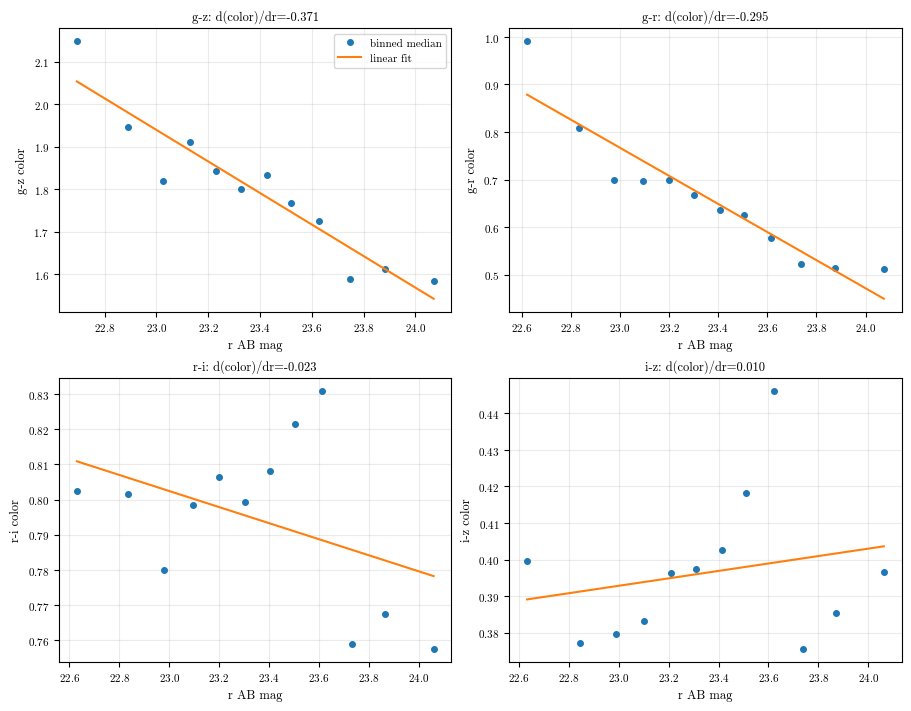

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(9, 7), constrained_layout=True)
for ax, color in zip(axes.flat, COLORS):
    sub = derivative_bins.loc[derivative_bins["color_name"] == color]
    if sub.empty:
        ax.text(0.5, 0.5, "no valid data", ha="center", va="center")
        ax.set_axis_off()
        continue
    ax.plot(sub["mag_median"], sub["color_median"], "o", ms=4, label="binned median")
    ax.plot(sub["mag_median"], sub["fit_color"], "-", lw=1.5, label="linear fit")
    slope = float(sub["slope_dcolor_dmag"].iloc[0])
    ax.set_title(f"{color}: d(color)/d{MAG_BAND}={slope:.3f}")
    ax.set_xlabel(f"{MAG_BAND} AB mag")
    ax.set_ylabel(f"{color} color")
    ax.grid(alpha=0.25)
axes.flat[0].legend(loc="best", fontsize=8)
fig.savefig(OUT_DIR / "color_magnitude_derivatives.png", dpi=180)
plt.show()

## Estimated Color Bias

The estimated magnification color shift is

`delta_color ~= (d color / d mag) * delta_mag_magnification`.

The table also compares that shift to the measured corrected stack signal and the jackknife uncertainty in the same radial bin, when those stack products are available.

In [27]:
median_delta_mag = float(np.nanmedian(magnification["delta_mag"]))
q16_delta_mag, q84_delta_mag = np.nanquantile(magnification["delta_mag"], [0.16, 0.84])

summary_rows = []
for _, row in derivatives.iterrows():
    color = row["color"]
    slope = float(row["slope_dcolor_dmag"])
    estimated_shift = slope * median_delta_mag
    estimated_shift_q16 = slope * q16_delta_mag
    estimated_shift_q84 = slope * q84_delta_mag

    stack_signal = np.nan
    stack_err = np.nan
    if stack_data is not None:
        if f"{color}_avg" in stack_data.files:
            stack_signal = float(np.asarray(stack_data[f"{color}_avg"])[BIN_INDEX])
        if f"{color}_err" in stack_data.files:
            stack_err = float(np.asarray(stack_data[f"{color}_err"])[BIN_INDEX])

    summary_rows.append(
        {
            "stack_id": STACK_ID,
            "radial_bin": bin_label,
            "color": color,
            "mag_band_for_derivative": MAG_BAND,
            "concentration": CONCENTRATION,
            "median_mu_minus_1": float(np.nanmedian(magnification["mu_minus_1"])),
            "median_delta_mag": median_delta_mag,
            "delta_mag_q16": float(q16_delta_mag),
            "delta_mag_q84": float(q84_delta_mag),
            "slope_dcolor_dmag": slope,
            "estimated_color_shift_mag": estimated_shift,
            "estimated_color_shift_q16_mag": estimated_shift_q16,
            "estimated_color_shift_q84_mag": estimated_shift_q84,
            "regular_stack_signal_mag": stack_signal,
            "jackknife_uncertainty_mag": stack_err,
            "shift_over_stack_signal": (
                estimated_shift / stack_signal
                if np.isfinite(stack_signal) and stack_signal != 0
                else np.nan
            ),
            "shift_over_jackknife_sigma": (
                estimated_shift / stack_err
                if np.isfinite(stack_err) and stack_err != 0
                else np.nan
            ),
        }
    )

summary = pd.DataFrame(summary_rows)
summary.to_csv(OUT_DIR / "magnification_bias_summary.csv", index=False)
display(summary)

,stack_id,radial_bin,color,mag_band_for_derivative,concentration,median_mu_minus_1,median_delta_mag,delta_mag_q16,delta_mag_q84,slope_dcolor_dmag,estimated_color_shift_mag,estimated_color_shift_q16_mag,estimated_color_shift_q84_mag,regular_stack_signal_mag,jackknife_uncertainty_mag,shift_over_stack_signal,shift_over_jackknife_sigma
0,dp1_default_pai24,bin1_10_15kpc,g-z,r,10.0,0.023202,-0.024903,-0.068586,-0.014279,-0.370863,0.009236,0.025436,0.005295,0.226599,0.098895,0.040758,0.093390
1,dp1_default_pai24,bin1_10_15kpc,g-r,r,10.0,0.023202,-0.024903,-0.068586,-0.014279,-0.295177,0.007351,0.020245,0.004215,0.129154,0.060104,0.056916,0.122303
2,dp1_default_pai24,bin1_10_15kpc,r-i,r,10.0,0.023202,-0.024903,-0.068586,-0.014279,-0.022833,0.000569,0.001566,0.000326,0.070436,0.031356,0.008073,0.018134
3,dp1_default_pai24,bin1_10_15kpc,i-z,r,10.0,0.023202,-0.024903,-0.068586,-0.014279,0.010154,-0.000253,-0.000696,-0.000145,0.049263,0.013166,-0.005133,-0.019208


In [28]:
gz = summary.loc[summary["color"].eq("g-z")].iloc[0]
paper_text = f"""
As a simple check on magnification bias, we approximated each foreground system as an NFW halo with concentration c={CONCENTRATION:.1f}, using the halo masses assigned to the DP1 foreground sample and the projected separations of the {r_min:g}-{r_max:g} kpc pairs. The resulting characteristic magnification is small: the median mu-1 is {gz['median_mu_minus_1']:.3g}, corresponding to a median magnitude perturbation of {gz['median_delta_mag']:.3g} mag. We then measured the empirical derivative of background-sample g-z color with respect to {MAG_BAND}-band magnitude, d(g-z)/d{MAG_BAND}={gz['slope_dcolor_dmag']:.3g}, and converted the magnification perturbation into an estimated color shift of {gz['estimated_color_shift_mag']:.3g} mag. This is {gz['shift_over_jackknife_sigma']:.3g} times the jackknife uncertainty and {gz['shift_over_stack_signal']:.3g} times the measured inner-bin g-z signal. Under these assumptions, magnification-induced color selection appears subdominant to the statistical uncertainty and is unlikely to explain the observed inner-bin reddening signal.
"""

display(Markdown("### Draft Paper Text"))
display(Markdown(paper_text.strip()))

### Draft Paper Text

As a simple check on magnification bias, we approximated each foreground system as an NFW halo with concentration c=10.0, using the halo masses assigned to the DP1 foreground sample and the projected separations of the 10-15 kpc pairs. The resulting characteristic magnification is small: the median mu-1 is 0.0232, corresponding to a median magnitude perturbation of -0.0249 mag. We then measured the empirical derivative of background-sample g-z color with respect to r-band magnitude, d(g-z)/dr=-0.371, and converted the magnification perturbation into an estimated color shift of 0.00924 mag. This is 0.0934 times the jackknife uncertainty and 0.0408 times the measured inner-bin g-z signal. Under these assumptions, magnification-induced color selection appears subdominant to the statistical uncertainty and is unlikely to explain the observed inner-bin reddening signal.